# Evaluación de modelos de clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk

# 1. Elige **cualquier** dataset

Puede ser cualquiera de los que hemos utilizado hasta ahora, o puedes buscar alguno en Kaggle (https://www.kaggle.com/) de algún tema que te guste.

In [2]:
!pip install kagglehub

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Download latest version
path = kagglehub.dataset_download("ajaypalsinghlo/world-happiness-report-2021")

print("Path to dataset files:", path)

# Load the latest version
df = pd.read_csv(path + "/world-happiness-report-2021.csv")

print("First 5 records:", df.head())

# del df['upperwhisker']
del df['upperwhisker']
del df['lowerwhisker']
del df['Explained by: Log GDP per capita']
del df['Explained by: Social support']
del df['Explained by: Healthy life expectancy']
del df['Explained by: Freedom to make life choices']
del df['Explained by: Generosity']
del df['Explained by: Perceptions of corruption']


/home/michele/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/michele/.cache/kagglehub/datasets/ajaypalsinghlo/world-happiness-report-2021/versions/2
First 5 records:   Country name Regional indicator  Ladder score  \
0      Finland     Western Europe         7.842   
1      Denmark     Western Europe         7.620   
2  Switzerland     Western Europe         7.571   
3      Iceland     Western Europe         7.554   
4  Netherlands     Western Europe         7.464   

   Standard error of ladder score  upperwhisker  lowerwhisker  \
0                           0.032         7.904         7.780   
1                           0.035         7.687         7.552   
2                           0.036         7.643         7.500   
3                           0.059         7.670         7.438   
4                           0.027         7.518         7.410   

   Logged GDP per capita  Social support  Healthy life expectancy  \
0                 10.775           0.954                     72.0   
1                 10.933      

In [4]:
print("First 5 records:", df.head())
np.shape(df)

First 5 records:   Country name Regional indicator  Ladder score  \
0      Finland     Western Europe         7.842   
1      Denmark     Western Europe         7.620   
2  Switzerland     Western Europe         7.571   
3      Iceland     Western Europe         7.554   
4  Netherlands     Western Europe         7.464   

   Standard error of ladder score  Logged GDP per capita  Social support  \
0                           0.032                 10.775           0.954   
1                           0.035                 10.933           0.954   
2                           0.036                 11.117           0.942   
3                           0.059                 10.878           0.983   
4                           0.027                 10.932           0.942   

   Healthy life expectancy  Freedom to make life choices  Generosity  \
0                     72.0                         0.949      -0.098   
1                     72.7                         0.946       0.030   
2  

(149, 12)

# 2. Elige **cualquier** modelo de clustering de los estudiados

K-means, Agglomerative Clustering, DBSCAN... el que prefieras, y entrénalo (guiándote en todo lo posible por el dataset que hayas elegido)

2030.8688751058423
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 1 1 0 1 1 0 1 0 0 0 0 0 1
 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1]
0.6167822536615047
1056.938874463283
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 2 2 0 0 0 2 2 0 2 2 2 2 2
 2 0 2 0 2 0 0 2 2 2 2 2 2 2 2 2 2 2 0 2 0 2 0 2 0 2 2 2 2 2 0 2 2 2 2 2 0
 2 2 0 2 2 2 2 2 1 2 1 2 2 2 0 2 1 1 2 2 1 1 2 1 1 1 2 1 1 2 1 2 2 2 2 2 1
 1 1 2 1 1 1 2 1 1 1 2 2 1 2 1 2 1 2 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1]
0.5454028115107757
641.7529535731632
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 0 2 2 2 0 0 0 2 2 0 2 2 2 2 2
 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 2 0 1 0 2 2 2 2 2 0 2 1 2 2 2 0
 2 2 0 2 2 1 2 1 1 2 3 2 2 2 0 2 3 1 2 2 1 3 1 3 3 1 2 3 1 2 1 2 2 2 2 2 1
 1 3 1 3 3 3 2 3 3 1 2 2 1 1 1 2 3 2 3 1 1 1 1 1 3 3 3 1 3 1 1 3 1 3 1 1 3

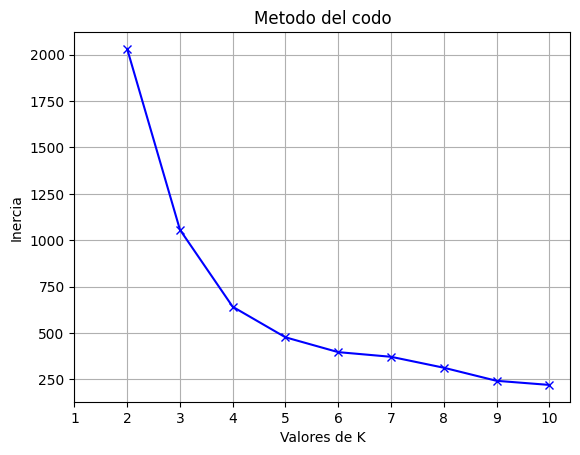

In [10]:
from sklearn.cluster import KMeans
k_n = [2,3,4,5,6,7,8,9,10]
inercias = []
scores = []
for k in k_n:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df.iloc[:, 2:12])
    print(kmeans.inertia_)
    inercias.append(kmeans.inertia_)

    C = kmeans.fit_predict(df.iloc[:, 2:12])
    print(C)
    score = sk.metrics.silhouette_score(df.iloc[:,2:12], C)
    print(score)
    scores.append(score)

plt.plot(range(2, 11), inercias, 'bx-')
plt.grid()
plt.xlabel('Valores de K')
plt.xticks(range(1, 11), range(1, 11))
plt.ylabel('Inercia')
plt.title('Metodo del codo')
plt.show()

# 3. Evalua el modelo utilizando el **silhouette score**

Tambien asignar aleatoriamente cada punto a un cluster para ver si nos sale negativo

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 2 2 0 0 0 2 2 0 2 2 2 2 2
 2 0 2 0 2 0 0 2 2 2 2 2 2 2 2 2 2 2 0 2 0 2 0 2 0 2 2 2 2 2 0 2 2 2 2 2 0
 2 2 0 2 2 2 2 2 1 2 1 2 2 2 0 2 1 1 2 2 1 1 2 1 1 1 2 1 1 2 1 2 2 2 2 2 1
 1 1 2 1 1 1 2 1 1 1 2 2 1 2 1 2 1 2 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1]
0.5454028115107757
    Country name  cluster
0        Finland        2
1        Denmark        1
2    Switzerland        1
3        Iceland        2
4    Netherlands        1
..           ...      ...
144      Lesotho        1
145     Botswana        0
146       Rwanda        1
147     Zimbabwe        0
148  Afghanistan        0

[149 rows x 2 columns]
Random: -0.04880983623129747


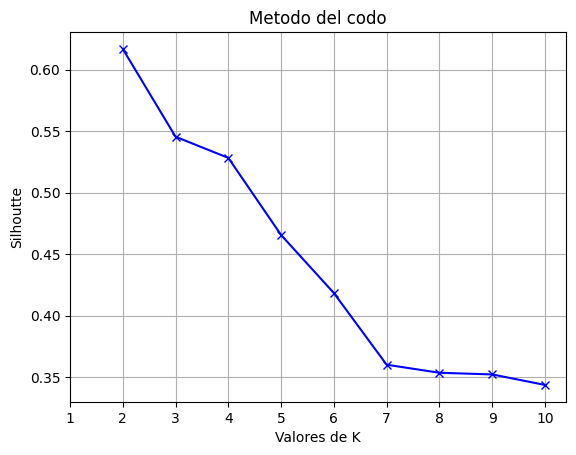

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42)
C = kmeans.fit_predict(df.iloc[:, 2:12])
print(C)
score = sk.metrics.silhouette_score(df.iloc[:,2:12], C)
print(score)

# Creiamo la colonna 'cluster' con valori casuali
df['cluster'] = np.random.randint(0, 3, size=len(df))

# Visualizziamo i primi risultati
print(df[['Country name', 'cluster']])
score_rand = sk.metrics.silhouette_score(df.iloc[:,2:12], df['cluster'])
print(f"Random:",score_rand)

plt.plot(range(2, 11), scores, 'bx-')
plt.grid()
plt.xlabel('Valores de K')
plt.xticks(range(1, 11), range(1, 11))
plt.ylabel('Silhoutte')
plt.title('Metodo del codo')
plt.show()

# 4. Elige un segundo modelo de clustering, entrénalo, evalúalo y compara los resultados

In [11]:
from sklearn.cluster import DBSCAN
epsilons = [2,3,4]
min_points = [3,4,5,]

score = []

for e in epsilons:
    for p in min_points:

        clustering = DBSCAN(eps=e, min_samples=p).fit(df.iloc[:,2:12])
        print(clustering.labels_)
        if len(set(clustering.labels_)) > 1:
            score_val = sk.metrics.silhouette_score(df.iloc[:,2:12], clustering.labels_)
            print(f"epsilon = {e}, min_points = {p}")
            print(score_val)
            score.append(score_val)
        else:
            print("Solo un cluster, no es posible computar silhoutte score")

        

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 -1  0  0  0  0]
epsilon = 2, min_points = 3
0.447504450586244
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 -1  0  0  0  0]
epsilon = 2, min_points = 4
0.44750445058624